# Mathematical Engineering - Financial Engineering, FY 2025-2026

# Buy Side - Exercise 4a: Statistical Arbitrage

Based on the paper "Statistical Arbitrage in the U.S. Equities Market" by Avellaneda & Lee (2008)


In [35]:
# Importing the libraries
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

from utilities.backtest import (backtest, portfolio_returns)
from utilities.covariance_utilities import prepare_rolling_estimation_window
from utilities.statistical_arbitrage import (
    estimate_factor_model,
    estimate_all_ou_parameters,
    estimate_ou_window_residuals,
    compute_s_score,
    compute_volume_adjusted_returns,
    generate_all_trading_signals,
    update_positions,
    compute_strategy_statistics,
    compute_portfolio_weights,
)

from utilities.principal_component_analysis import (principal_component_analysis)

In [36]:
# Reading the data
data_path = Path("data") # !! COMPLETE AS APPROPRIATE !!!

last_prices = pd.read_csv(
    data_path / "sx5e_underlyings.csv", index_col="Date", parse_dates=True
).ffill()

# Volume data for trading-time adjustment
volume = pd.read_csv(
    data_path / "volume.csv",
    index_col="Date",
    parse_dates=True,
)


In [37]:
performance = last_prices.pct_change().iloc[1:]

In [38]:
# Parameters
estimation_window = 1 * 252  # 1 year of data for PCA factor model estimation # error spotted
ou_estimation_window = 60  # 60 business days for O-U estimation
n_factors = 4  # Number of PCA factors   # error spotted

# Trading signal parameters
s_bo = 1.25  # Buy to open threshold
s_so = 1.25  # Sell to open threshold
s_bc = 0.50  # Buy to close threshold   # error spotted
s_sc = 0.50  # Sell to close threshold

# O-U filter
min_mean_reversion_speed = 252 / 30 # 8.4

min_coverage = 0.95
transaction_costs = 5e-4 # error spotted, 5 bp

# 1. Understanding PCA-based Factor Models

The statistical arbitrage approach by Avellaneda & Lee uses Principal Component Analysis (PCA) to extract systematic risk factors from stock returns. The idea is:

1. **Factor Model**: Decompose each stock's return as:
   $$R_{i,t} = \alpha_i + \sum_{j=1}^{K} \beta_{i,j} F_{j,t} + \epsilon_{i,t}$$

   where $F_j$ are the principal component factors.

2. **Residual Returns**: The residuals $\epsilon_{i,t}$ represent the idiosyncratic (stock-specific) returns.

3. **Mean Reversion**: The cumulative residuals $X_{i,t} = \sum_{s=1}^{t} \epsilon_{i,s}$ are modeled as mean-reverting Ornstein-Uhlenbeck processes.


In [39]:
# Example: Estimate factor model on the first estimation window
calibration_date = None
for date in performance.index:
    candidate_window = prepare_rolling_estimation_window(
        returns=performance,
        rebalance_date=date,
        lookback=estimation_window,
        min_coverage=min_coverage,
    )
    if candidate_window.shape[0] == estimation_window and candidate_window.shape[1] > 0:
        calibration_date = date
        calibration_window = candidate_window
        break

print(
    f"First estimation window: {calibration_window.index[0].date()} to {calibration_window.index[-1].date()}"
)
print(f"Number of observations: {len(calibration_window)}")
print(f"Number of assets: {calibration_window.shape[1]}")

First estimation window: 2013-01-03 to 2013-12-24
Number of observations: 252
Number of assets: 46


In [40]:
# Estimate the factor model
factor_model = estimate_factor_model(calibration_window, n_factors=n_factors)

print(f"Number of factors used: {factor_model['n_factors']}")
print("\nExplained variance by each factor:")
for i, ev in enumerate(factor_model["explained_variance"]):
    print(f"  PC{i + 1}: {ev:.2%}")
print(f"\nTotal explained variance: {factor_model['explained_variance'].sum():.2%}")

Number of factors used: 4

Explained variance by each factor:
  PC1: 43.08%
  PC2: 5.75%
  PC3: 3.91%
  PC4: 2.71%

Total explained variance: 55.44%


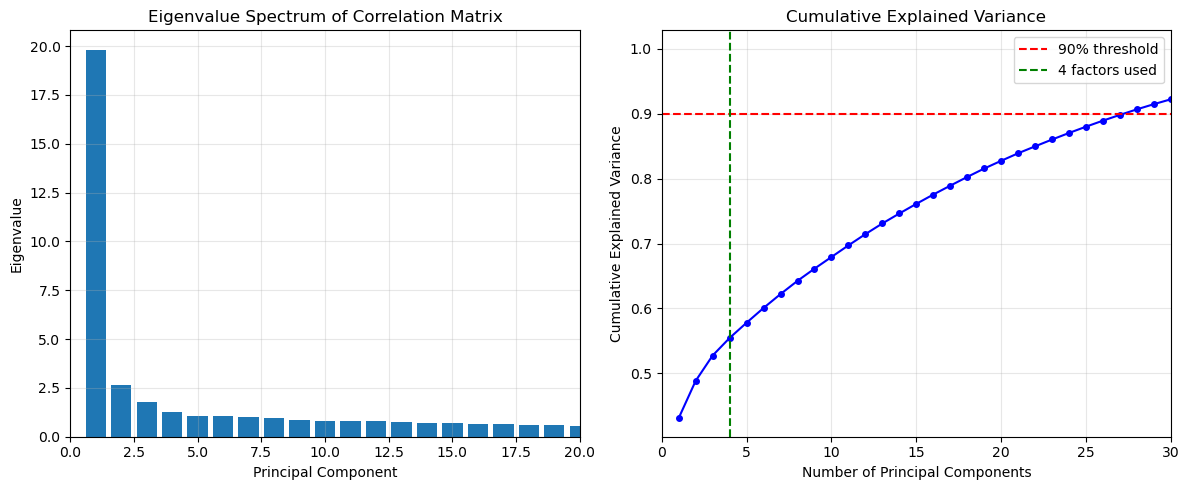

In [41]:
# Plot eigenvalue spectrum
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.bar(range(1, len(factor_model["eigenvalues"]) + 1), factor_model["eigenvalues"])
plt.xlabel("Principal Component")
plt.ylabel("Eigenvalue")
plt.title("Eigenvalue Spectrum of Correlation Matrix")
plt.xlim(0, 20)
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
cumulative_var = (
    np.cumsum(factor_model["eigenvalues"]) / factor_model["eigenvalues"].sum()
)
plt.plot(range(1, len(cumulative_var) + 1), cumulative_var, "b-o", markersize=4)
plt.axhline(y=0.9, color="r", linestyle="--", label="90% threshold")
plt.axvline(x=n_factors, color="g", linestyle="--", label=f"{n_factors} factors used")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.legend()
plt.grid(alpha=0.3)
plt.xlim(0, 30)

plt.tight_layout()
plt.show()

# 2. Ornstein-Uhlenbeck Process for Residuals

The cumulative residuals are modeled as an Ornstein-Uhlenbeck (O-U) process:

$$dX_t = \kappa (m - X_t) dt + \sigma dW_t$$

where:

- $\kappa$ is the **mean-reversion speed** (how fast the process reverts to the mean)
- $m$ is the **equilibrium level** (long-term mean)
- $\sigma$ is the **volatility** of the process

The **equilibrium standard deviation** is: $\sigma_{eq} = \frac{\sigma}{\sqrt{2\kappa}}$

The **half-life** of mean reversion is: $\tau_{1/2} = \frac{\ln(2)}{\kappa}$


In [42]:
# Compute cumulative residuals
ou_residuals_output = estimate_ou_window_residuals(
    candidate_window, factor_model["factors"], ou_estimation_window
)
cumulative_residuals = ou_residuals_output["residuals"]
alphas = ou_residuals_output["alphas"]   # from the 60day O-U estimation

# Estimate O-U parameters
cum_residuals_ou = cumulative_residuals.iloc[-ou_estimation_window:]
ou_params = estimate_all_ou_parameters(cum_residuals_ou, dt=1 / 252, center_ou_means=False)

# Display O-U parameters for a few assets
print(
    f"O-U Parameters for selected assets ({ou_estimation_window}-day window, centered means):"
)
print(f"{'Asset':<15} {'Kappa':>10} {'Half-life':>12} {'Sigma_eq':>12} {'m':>10}")
print("-" * 60)
for asset in list(ou_params.keys())[:10]:
    params = ou_params[asset]
    half_life_days = params["half_life"] * 252
    print(
        f"{asset:<15} {params['kappa']:>10.2f} {half_life_days:>10.1f} d {params['sigma_eq']:>12.4f} {params['m']:>10.4f}"
    )

O-U Parameters for selected assets (60-day window, centered means):
Asset                Kappa    Half-life     Sigma_eq          m
------------------------------------------------------------
ABI.BR               60.15        2.9 d       0.0100     0.0030
AD.AS                15.27       11.4 d       0.0302     0.0304
ADSGn.DE             16.83       10.4 d       0.0190     0.0210
AIR.PA               45.27        3.9 d       0.0235    -0.0129
AIRP.PA              28.12        6.2 d       0.0096    -0.0054
ALVG.DE              47.54        3.7 d       0.0080     0.0033
ASML.AS              19.00        9.2 d       0.0230    -0.0157
AXAF.PA              45.64        3.8 d       0.0134    -0.0079
BASFn.DE             18.33        9.5 d       0.0126     0.0141
BAYGn.DE            144.81        1.2 d       0.0072    -0.0071


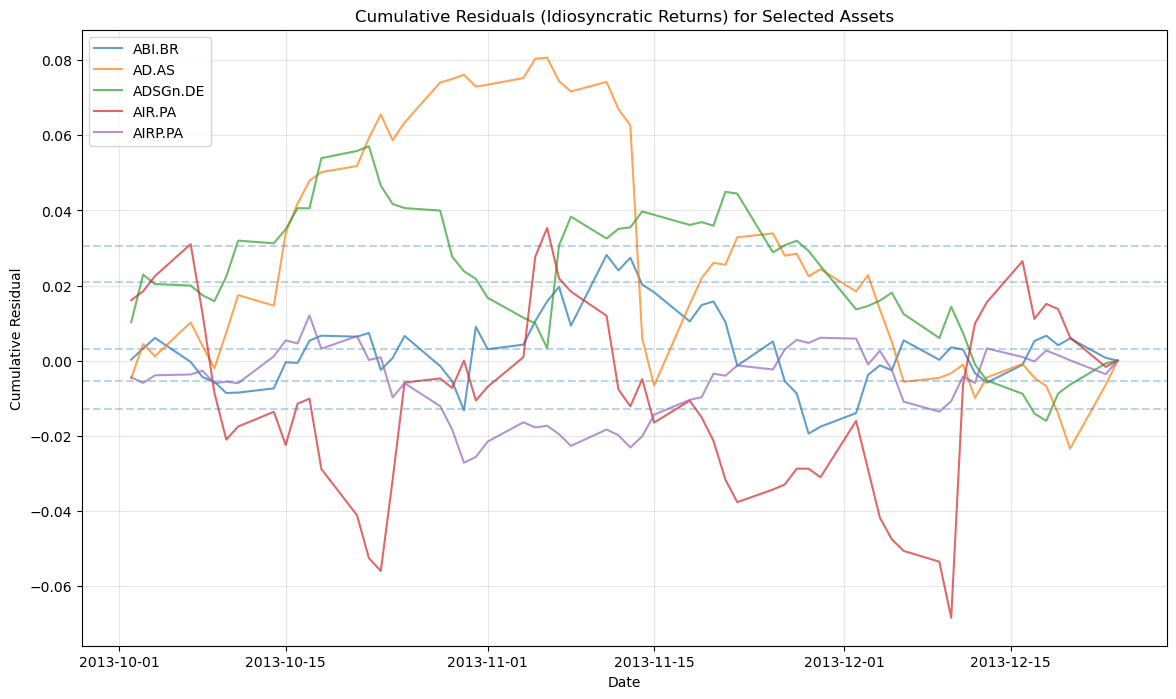

In [43]:
# Plot cumulative residuals for a few assets
sample_assets = list(cumulative_residuals.columns)[:5]

plt.figure(figsize=(14, 8))
for asset in sample_assets:
    plt.plot(
        cumulative_residuals.index, cumulative_residuals[asset], label=asset, alpha=0.7
    )
    # Add equilibrium level
    m = ou_params[asset]["m"]
    plt.axhline(y=m, linestyle="--", alpha=0.3)

plt.xlabel("Date")
plt.ylabel("Cumulative Residual")
plt.title("Cumulative Residuals (Idiosyncratic Returns) for Selected Assets")
plt.legend(loc="upper left")
plt.grid(alpha=0.3)
plt.show()

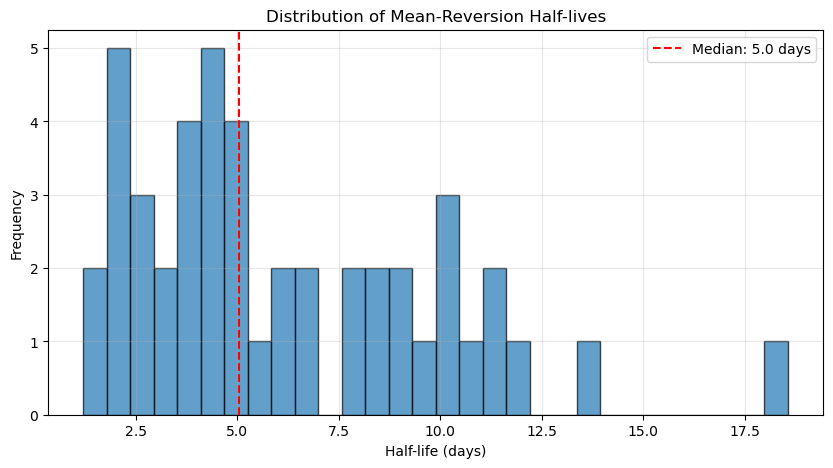

Half-life statistics:
  Mean: 6.2 days
  Median: 5.0 days
  Std: 3.8 days


In [44]:
# Distribution of half-lives
half_lives = pd.Series(
    {asset: params["half_life"] * 252 for asset, params in ou_params.items()}
)
half_lives = half_lives[half_lives < 100]  # Filter outliers

plt.figure(figsize=(10, 5))
plt.hist(half_lives, bins=30, edgecolor="black", alpha=0.7)
plt.xlabel("Half-life (days)")
plt.ylabel("Frequency")
plt.title("Distribution of Mean-Reversion Half-lives")
plt.axvline(
    half_lives.median(),
    color="r",
    linestyle="--",
    label=f"Median: {half_lives.median():.1f} days",
)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("Half-life statistics:")
print(f"  Mean: {half_lives.mean():.1f} days")
print(f"  Median: {half_lives.median():.1f} days")
print(f"  Std: {half_lives.std():.1f} days")

# 3. S-Score and Trading Signals

The modified **s-score** measures how far the current cumulative residual is from its equilibrium, accounting for the residual drift:

$$s_{mod, t} = s_t - \frac{\alpha}{\kappa \sigma_{eq}} =  \frac{X_t - m}{\sigma_{eq}} - \frac{\alpha}{\kappa \sigma_{eq}} $$

Trading rules:

- **Buy to Open** (enter long): $s < -s_{bo}$ (price is too low)
- **Sell to Close** (exit long): $s > -s_{bc}$ (price recovered)
- **Sell to Open** (enter short): $s > s_{so}$ (price is too high)
- **Buy to Close** (exit short): $s < s_{sc}$ (price reverted)


In [45]:
# Compute s-scores
alphas = ou_residuals_output["alphas"]
s_scores = compute_s_score(cumulative_residuals, ou_params, alphas, True)

print("S-score statistics across all assets:")
print(
    f"  Mean: {s_scores.values.flatten()[~np.isnan(s_scores.values.flatten())].mean():.2f}"
)
print(
    f"  Std: {s_scores.values.flatten()[~np.isnan(s_scores.values.flatten())].std():.2f}"
)
print(f"  Min: {np.nanmin(s_scores.values):.2f}")
print(f"  Max: {np.nanmax(s_scores.values):.2f}")

S-score statistics across all assets:
  Mean: 0.02
  Std: 1.17
  Min: -3.72
  Max: 3.85


In [46]:
valid_assets = [
    asset for asset in ou_params
    if ou_params[asset]["kappa"] > 252 / 30
]
s_scores = s_scores[valid_assets]

print("S-score statistics across all assets after filtering:")
print(
    f"  Mean: {s_scores.values.flatten()[~np.isnan(s_scores.values.flatten())].mean():.2f}"
)
print(
    f"  Std: {s_scores.values.flatten()[~np.isnan(s_scores.values.flatten())].std():.2f}"
)
print(f"  Min: {np.nanmin(s_scores.values):.2f}")
print(f"  Max: {np.nanmax(s_scores.values):.2f}")

S-score statistics across all assets after filtering:
  Mean: 0.02
  Std: 1.17
  Min: -3.72
  Max: 3.85


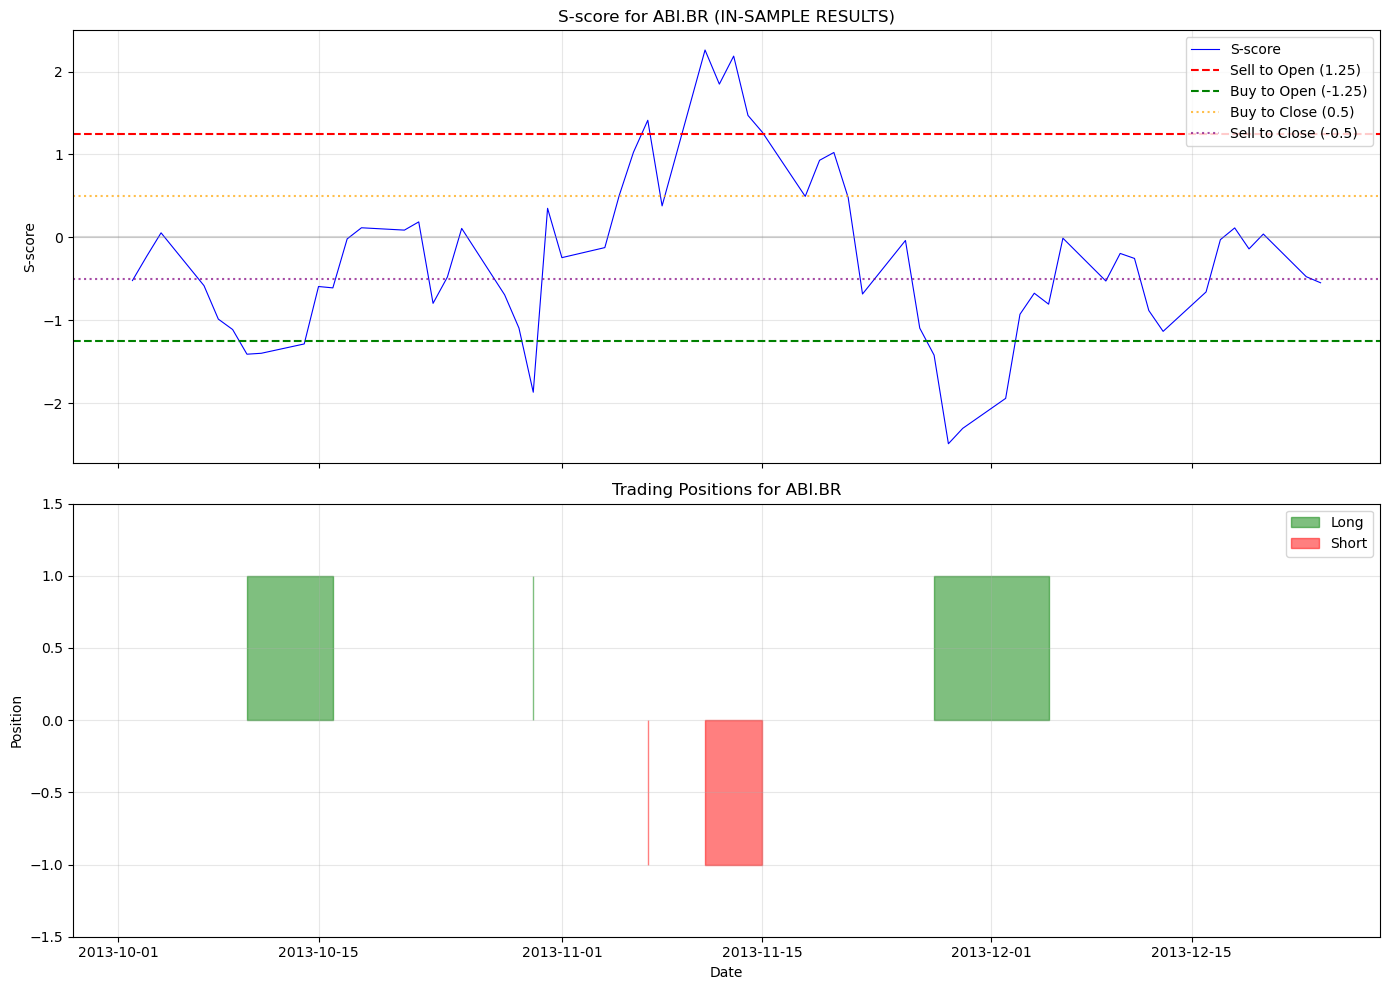

In [47]:
# Plot s-score for a single asset
sample_asset = sample_assets[0]

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Top: S-score with thresholds
ax1 = axes[0]
ax1.plot(s_scores.index, s_scores[sample_asset], "b-", linewidth=0.8, label="S-score")
ax1.axhline(y=s_so, color="r", linestyle="--", label=f"Sell to Open ({s_so})")
ax1.axhline(y=-s_bo, color="g", linestyle="--", label=f"Buy to Open ({-s_bo})")
ax1.axhline(
    y=s_sc, color="orange", linestyle=":", alpha=0.7, label=f"Buy to Close ({s_sc})"
)
ax1.axhline(
    y=-s_bc, color="purple", linestyle=":", alpha=0.7, label=f"Sell to Close ({-s_bc})"
)
ax1.axhline(y=0, color="gray", linestyle="-", alpha=0.3)
ax1.set_ylabel("S-score")
ax1.set_title(f"S-score for {sample_asset} (IN-SAMPLE RESULTS)")
ax1.legend(loc="upper right")
ax1.grid(alpha=0.3)

# Bottom: Trading signals
positions = generate_all_trading_signals(
    s_scores[[sample_asset]], s_bo=s_bo, s_so=s_so, s_bc=s_bc, s_sc=s_sc
)
ax2 = axes[1]
ax2.fill_between(
    positions.index,
    0,
    positions[sample_asset],
    where=positions[sample_asset] > 0,
    color="green",
    alpha=0.5,
    label="Long",
)
ax2.fill_between(
    positions.index,
    0,
    positions[sample_asset],
    where=positions[sample_asset] < 0,
    color="red",
    alpha=0.5,
    label="Short",
)
ax2.set_ylabel("Position")
ax2.set_xlabel("Date")
ax2.set_title(f"Trading Positions for {sample_asset}")
ax2.legend()
ax2.grid(alpha=0.3)
ax2.set_ylim(-1.5, 1.5)

plt.tight_layout()
plt.show()

# 4. Rolling Backtest of Statistical Arbitrage Strategy

We now implement a rolling backtest where:

1. At each trading day, we re-estimate the factor model (252-day window) and O-U parameters (60-day window)
2. We compute s-scores and update trading positions **maintaining state across days**
3. We track the portfolio performance


In [48]:
# Storage for results
all_positions = {}
all_s_scores = {}
all_ou_params = {}
all_factor_models = {}

current_positions: dict[str, float] = {}

for rebalance_date in performance.index:
    cur_performance, cur_window_diagnostics = prepare_rolling_estimation_window(
        returns=performance,
        rebalance_date=rebalance_date,
        lookback=estimation_window,
        min_coverage=min_coverage,
        return_diagnostics=True,
    )
    if (
        cur_window_diagnostics["row_count"] < estimation_window
        or cur_performance.shape[1] == 0
    ):
        continue

    reb_date = rebalance_date.to_pydatetime().date()
    print(f"Processing: {reb_date}")

    # 1. Estimate factor model
    factor_model = estimate_factor_model(cur_performance, n_factors=n_factors)
    all_factor_models[reb_date] = factor_model

    # 2. Compute the residuals needed to estimate the mean-reversion parameters
    ou_residuals_output = estimate_ou_window_residuals(
        cur_performance, factor_model["factors"], ou_estimation_window)
    alphas = ou_residuals_output["alphas"]
    cumulative_residuals = ou_residuals_output["residuals"]

    cum_residuals_ou = cumulative_residuals.iloc[-ou_estimation_window:]

    # 3. Estimate O-U parameters
    ou_params = estimate_all_ou_parameters(cum_residuals_ou, dt=1 / 252, center_ou_means=False)
    all_ou_params[reb_date] = ou_params

    # 4. Filter assets
    valid_assets = [
    asset for asset in ou_params
    if ou_params[asset]["kappa"] > 252 / 30 ]

    # 5. S-score
    s_scores = compute_s_score(cumulative_residuals, ou_params, alphas, True)
    cur_s_scores = s_scores[valid_assets].iloc[-1]
    all_s_scores[reb_date] = cur_s_scores

    # Update positions carrying over previous day's state
    current_positions = update_positions(
        current_positions=current_positions,
        cur_s_scores=cur_s_scores,
        valid_assets=valid_assets,
        s_bo=s_bo,
        s_so=s_so,
        s_bc=s_bc,
        s_sc=s_sc,
    )
    all_positions[reb_date] = current_positions.copy()

Processing: 2013-12-24
Processing: 2013-12-27
Processing: 2013-12-30
Processing: 2013-12-31
Processing: 2014-01-02
Processing: 2014-01-03
Processing: 2014-01-06
Processing: 2014-01-07
Processing: 2014-01-08
Processing: 2014-01-09
Processing: 2014-01-10
Processing: 2014-01-13
Processing: 2014-01-14
Processing: 2014-01-15
Processing: 2014-01-16
Processing: 2014-01-17
Processing: 2014-01-20
Processing: 2014-01-21
Processing: 2014-01-22
Processing: 2014-01-23
Processing: 2014-01-24
Processing: 2014-01-27
Processing: 2014-01-28
Processing: 2014-01-29
Processing: 2014-01-30
Processing: 2014-01-31
Processing: 2014-02-03
Processing: 2014-02-04
Processing: 2014-02-05
Processing: 2014-02-06
Processing: 2014-02-07
Processing: 2014-02-10
Processing: 2014-02-11
Processing: 2014-02-12
Processing: 2014-02-13
Processing: 2014-02-14
Processing: 2014-02-17
Processing: 2014-02-18
Processing: 2014-02-19
Processing: 2014-02-20
Processing: 2014-02-21
Processing: 2014-02-24
Processing: 2014-02-25
Processing:

In [51]:
# Build portfolio weights time series
positions_df = pd.DataFrame(all_positions).T
positions_df.index = pd.to_datetime(positions_df.index)
positions_df = positions_df.fillna(0)

# Equal weight among active positions
weights = compute_portfolio_weights(positions_df) # error spotted 

print("Position statistics:")
print(f"  Total rebalance dates: {len(positions_df)}")
print(
    f"  Average number of long positions: {(positions_df > 0).sum(axis=1).mean():.1f}"
)
print(
    f"  Average number of short positions: {(positions_df < 0).sum(axis=1).mean():.1f}"
)
print(f"  Average total positions: {(positions_df != 0).sum(axis=1).mean():.1f}")

Position statistics:
  Total rebalance dates: 2347
  Average number of long positions: 10.2
  Average number of short positions: 10.0
  Average total positions: 20.1


In [52]:
b_values = []
for date, params in all_ou_params.items():
    for asset, p in params.items():
        b_values.append(p["b"])

b_series = pd.Series(b_values)
print(f"b < 0:      {(b_series < 0).mean():.2%}")
print(f"b > 1:      {(b_series > 1).mean():.2%}")
print(f"0 < b < 1:  {((b_series > 0) & (b_series < 1)).mean():.2%}")

b < 0:      0.00%
b > 1:      0.01%
0 < b < 1:  99.99%


In [53]:
# Backtest the strategy
cumulative_returns = backtest(weights, performance)
cumulative_returns_with_costs = backtest(
    weights, performance, transaction_costs=transaction_costs
)
cumulative_returns_base=cumulative_returns

# Compute strategy statistics
stats = compute_strategy_statistics(cumulative_returns.dropna())
stats_with_costs = compute_strategy_statistics(cumulative_returns_with_costs.dropna())

print("Strategy Performance:")
print(f"  Total Return: {stats['total_return']:.2%}")
print(f"  Annualized Return: {stats['annualized_return']:.2%}")
print(f"  Annualized Volatility: {stats['annualized_volatility']:.2%}")
print(f"  Sharpe Ratio: {stats['sharpe_ratio']:.2f}")
print(f"  Maximum Drawdown: {stats['max_drawdown']:.2%}")

print("\nStrategy Performance with Transaction Costs:")
print(f"  Total Return: {stats_with_costs['total_return']:.2%}")
print(f"  Annualized Return: {stats_with_costs['annualized_return']:.2%}")
print(f"  Annualized Volatility: {stats_with_costs['annualized_volatility']:.2%}")
print(f"  Sharpe Ratio: {stats_with_costs['sharpe_ratio']:.2f}")
print(f"  Maximum Drawdown: {stats_with_costs['max_drawdown']:.2%}")

Strategy Performance:
  Total Return: 31.85%
  Annualized Return: 3.02%
  Annualized Volatility: 5.60%
  Sharpe Ratio: 0.54
  Maximum Drawdown: -8.50%

Strategy Performance with Transaction Costs:
  Total Return: 0.67%
  Annualized Return: 0.07%
  Annualized Volatility: 5.60%
  Sharpe Ratio: 0.01
  Maximum Drawdown: -9.75%


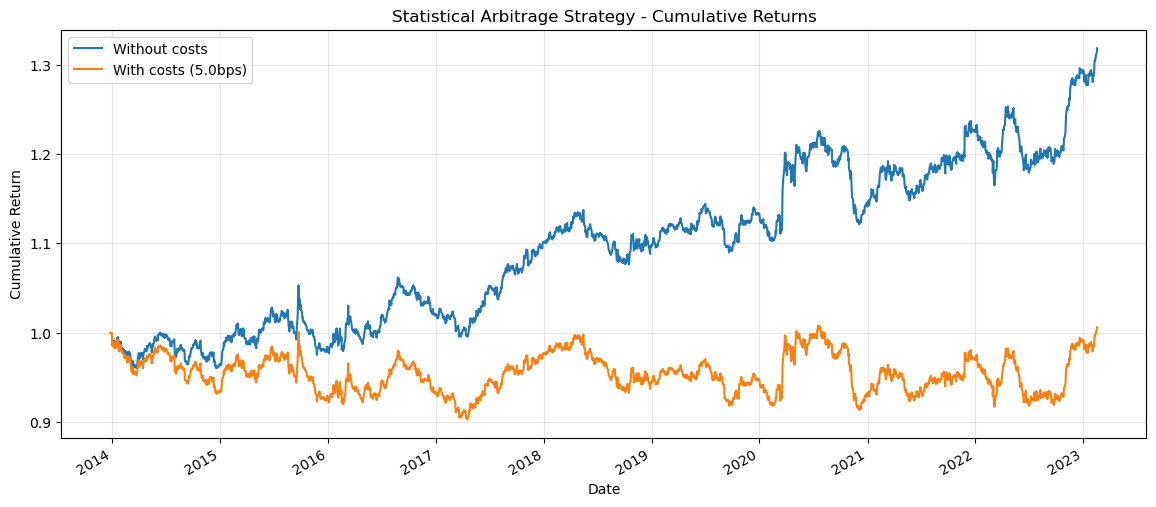

In [54]:
# Plot cumulative returns
plt.figure(figsize=(14, 6))
cumulative_returns.plot(label="Without costs", linewidth=1.5)
cumulative_returns_with_costs.plot(
    label=f"With costs ({transaction_costs * 1e4:.1f}bps)", linewidth=1.5
)

plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.title("Statistical Arbitrage Strategy - Cumulative Returns")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

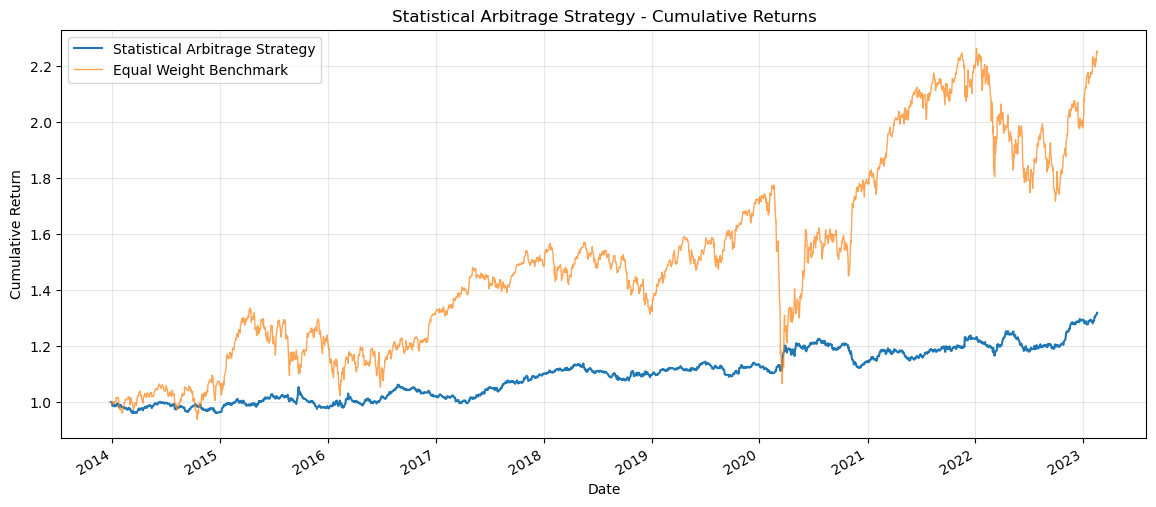

In [55]:
# Plot cumulative returns
plt.figure(figsize=(14, 6))
cumulative_returns.plot(label="Statistical Arbitrage Strategy", linewidth=1.5)

# Add benchmark (equal-weighted portfolio)
equal_weight_benchmark = (1 + performance.mean(axis=1)).cumprod()
equal_weight_benchmark = equal_weight_benchmark.reindex(
    cumulative_returns.index
).ffill()
equal_weight_benchmark = (
    equal_weight_benchmark / equal_weight_benchmark.iloc[0] * cumulative_returns.iloc[0]
)
equal_weight_benchmark.plot(label="Equal Weight Benchmark", linewidth=1, alpha=0.7)


plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.title("Statistical Arbitrage Strategy - Cumulative Returns")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

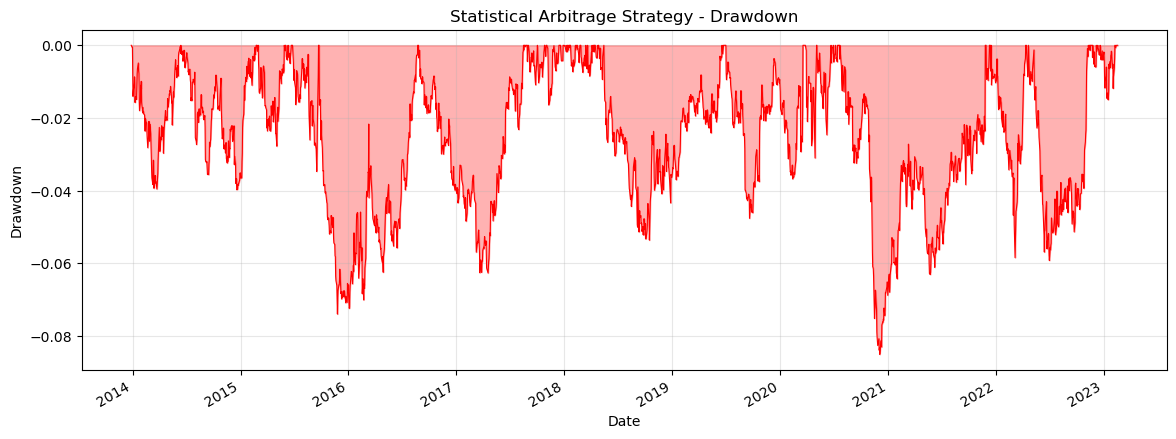

In [56]:
# Plot drawdown
rolling_max = cumulative_returns.cummax()
drawdown = (cumulative_returns - rolling_max) / rolling_max

plt.figure(figsize=(14, 5))
drawdown.plot(color="red", linewidth=0.8)
plt.fill_between(drawdown.index, 0, drawdown.values, color="red", alpha=0.3)
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.title("Statistical Arbitrage Strategy - Drawdown")
plt.grid(alpha=0.3)
plt.show()

# 5. Analysis of Strategy Characteristics


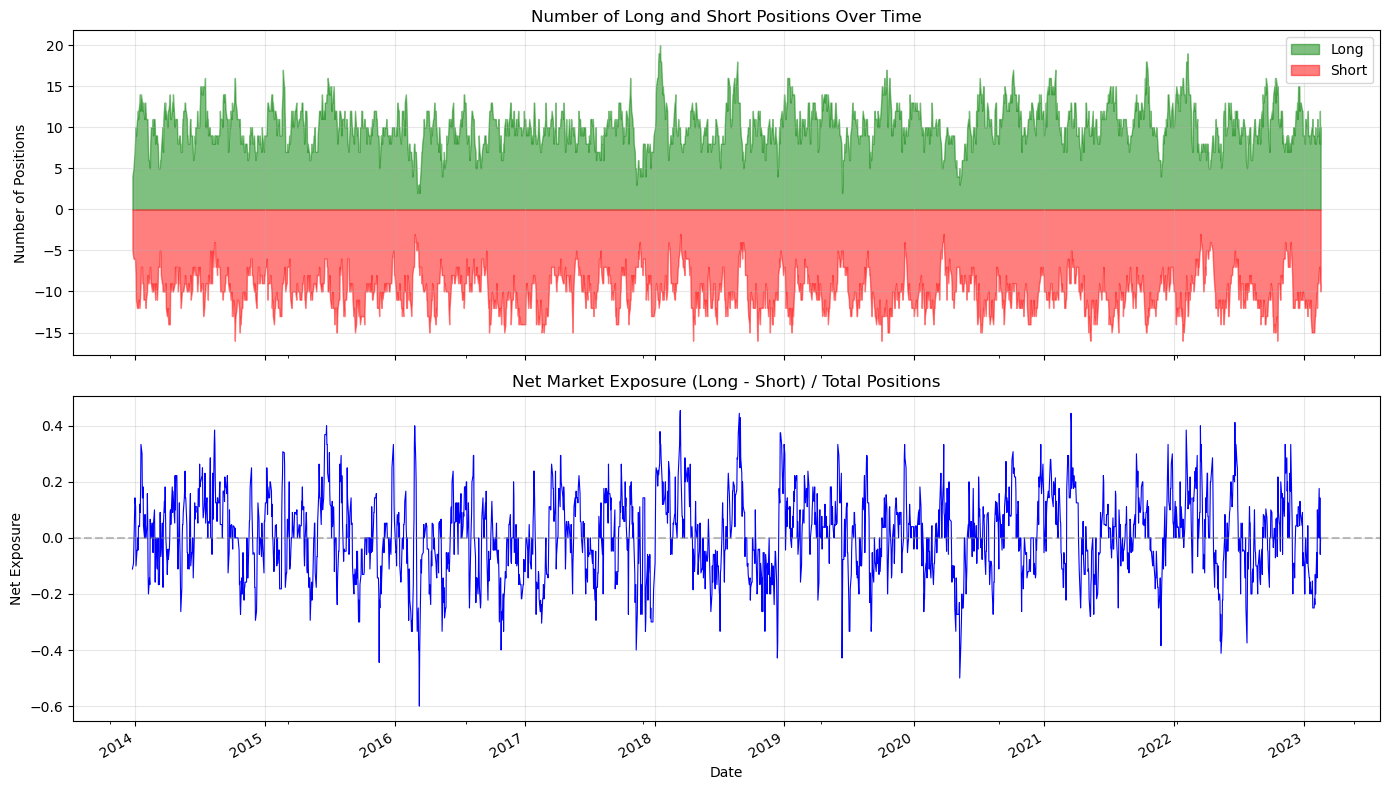

In [57]:
# Number of positions over time
n_long = (positions_df > 0).sum(axis=1)
n_short = (positions_df < 0).sum(axis=1)
n_total = (positions_df != 0).sum(axis=1)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax1 = axes[0]
ax1.fill_between(n_long.index, 0, n_long.values, color="green", alpha=0.5, label="Long")
ax1.fill_between(
    n_short.index, 0, -n_short.values, color="red", alpha=0.5, label="Short"
)
ax1.set_ylabel("Number of Positions")
ax1.set_title("Number of Long and Short Positions Over Time")
ax1.legend()
ax1.grid(alpha=0.3)

ax2 = axes[1]
net_exposure = positions_df.sum(axis=1) / n_total.replace(0, np.nan)
net_exposure.plot(ax=ax2, color="blue", linewidth=0.8)
ax2.axhline(y=0, color="gray", linestyle="--", alpha=0.5)
ax2.set_ylabel("Net Exposure")
ax2.set_xlabel("Date")
ax2.set_title("Net Market Exposure (Long - Short) / Total Positions")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

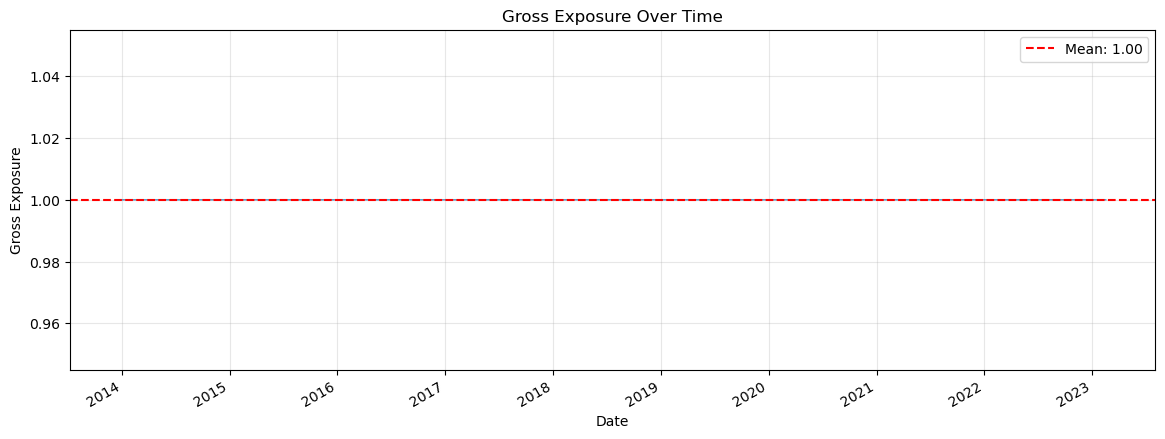

In [58]:
# Gross exposure over time
gross_exposure = weights.abs().sum(axis=1).round(6)

plt.figure(figsize=(14, 5))
gross_exposure.plot(linewidth=0.8)
plt.axhline(
    y=gross_exposure.mean(),
    color="r",
    linestyle="--",
    label=f"Mean: {gross_exposure.mean():.2f}",
)
plt.xlabel("Date")
plt.ylabel("Gross Exposure")
plt.title("Gross Exposure Over Time")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

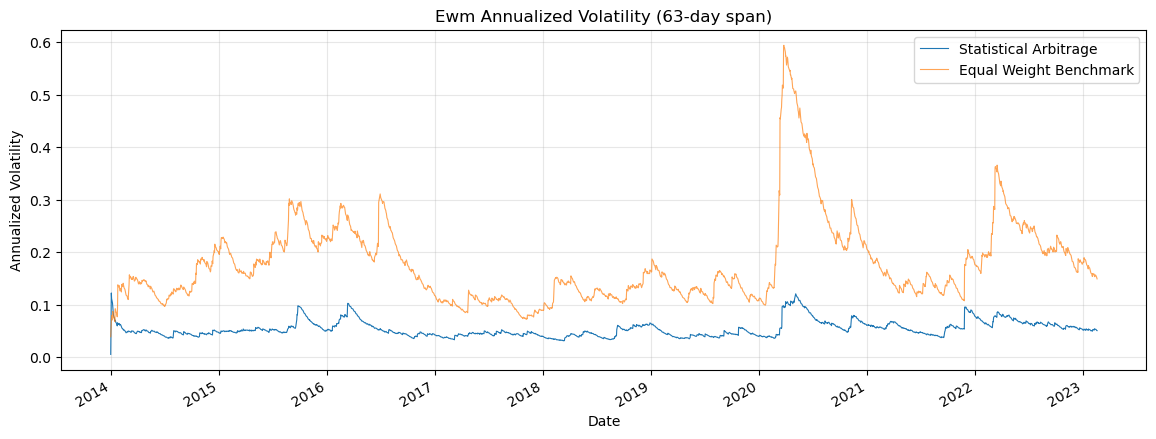

In [59]:
# Ewm volatility of strategy returns
strategy_returns = cumulative_returns.pct_change().dropna()
ewm_vol = strategy_returns.ewm(span=63).std() * np.sqrt(252)

benchmark_returns = equal_weight_benchmark.pct_change().dropna()
benchmark_ewm_vol = benchmark_returns.ewm(span=63).std() * np.sqrt(252)

plt.figure(figsize=(14, 5))
ewm_vol.plot(label="Statistical Arbitrage", linewidth=0.8)
benchmark_ewm_vol.plot(label="Equal Weight Benchmark", linewidth=0.8, alpha=0.7)
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.title("Ewm Annualized Volatility (63-day span)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 6. Sensitivity Analysis

## 6.1 Sensitivity to s-score entry threshold


In [ ]:
thresholds = [1.0, 1.25, 1.5, 2.0]

results_with_costs = {}

for threshold in thresholds:

    print(f"\nRunning threshold = {threshold}")

    s_bo_test = threshold
    s_so_test = threshold

    current_positions = {}
    test_positions = {}

    for reb_date, cur_s_scores in all_s_scores.items():

        valid_assets = cur_s_scores.index.tolist()

        current_positions = update_positions(
            current_positions=current_positions,
            cur_s_scores=cur_s_scores,
            valid_assets=valid_assets,
            s_bo=s_bo_test,
            s_so=s_so_test,
            s_bc=s_bc,
            s_sc=s_sc,
        )

        test_positions[reb_date] = current_positions.copy()

    # Build portfolio weights
    test_positions_df = pd.DataFrame(test_positions).T
    test_positions_df.index = pd.to_datetime(test_positions_df.index)
    test_positions_df = test_positions_df.fillna(0)

    test_weights = compute_portfolio_weights(test_positions_df)

    # Backtest WITH costs only
    cumulative_returns_threshold = backtest(
        test_weights,
        performance,
        transaction_costs=transaction_costs
    )

    results_with_costs[threshold] = cumulative_returns_threshold


print("\nPerformance by Entry Threshold")
print("=" * 60)

header = f"{'Threshold':>10} | {'Ann.Return':>12} | {'Ann.Vol':>10} | {'Sharpe':>8} | {'Max DD':>10}"
print(header)
print("-" * len(header))

for s_bo_val, cum_ret in results_with_costs.items():

    stats_test = compute_strategy_statistics(cum_ret.dropna())

    row = (
        f"{s_bo_val:>10.2f} | "
        f"{stats_test['annualized_return']:>11.2%} | "
        f"{stats_test['annualized_volatility']:>9.2%} | "
        f"{stats_test['sharpe_ratio']:>7.2f} | "
        f"{stats_test['max_drawdown']:>9.2%}"
    )

    print(row)


Running threshold = 1.0

Running threshold = 1.25

Running threshold = 1.5

Running threshold = 2.0

Performance by Entry Threshold
 Threshold |   Ann.Return |    Ann.Vol |   Sharpe |     Max DD
--------------------------------------------------------------
      1.00 |      -0.22% |     4.98% |   -0.04 |   -14.01%
      1.25 |       0.07% |     5.60% |    0.01 |    -9.75%
      1.50 |      -0.63% |     6.70% |   -0.09 |   -20.94%
      2.00 |      -3.94% |     9.81% |   -0.40 |   -37.25%


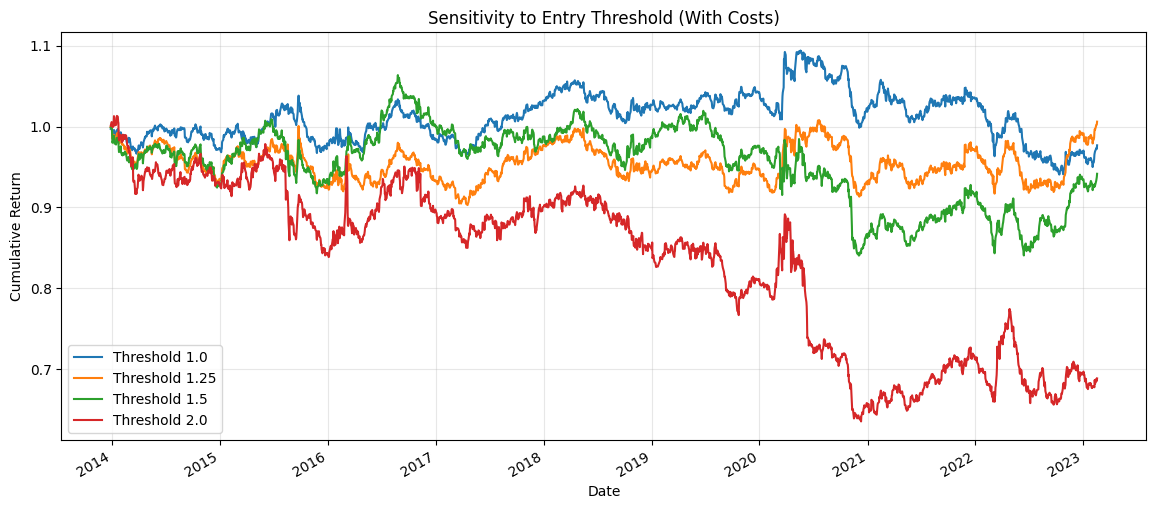

In [70]:
plt.figure(figsize=(14,6))

for th, perf in results_with_costs.items():
    perf.plot(label=f"Threshold {th}", linewidth=1.5)

plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.title("Sensitivity to Entry Threshold (With Costs)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 6.2 Fixed factors vs variable factor selection


In [ ]:
explained_variance_targets = [0.40, 0.55, 0.65, 0.75]

results_with_costs = {}
n_factors_time_series = {}

s_bo = 1.25

for var_target in explained_variance_targets:

    print(f"Running strategy with explained variance target = {var_target}")

    all_positions = {}
    current_positions = {}
    n_factors_series = {}

    for rebalance_date in performance.index:

        cur_performance, cur_window_diagnostics = prepare_rolling_estimation_window(
            returns=performance,
            rebalance_date=rebalance_date,
            lookback=estimation_window,
            min_coverage=min_coverage,
            return_diagnostics=True,
        )

        if (
            cur_window_diagnostics["row_count"] < estimation_window
            or cur_performance.shape[1] == 0
        ):
            continue

        reb_date = rebalance_date.to_pydatetime().date()

        # ===== PCA =====
        if reb_date not in all_factor_models:
            continue

        eigenvalues = all_factor_models[reb_date]["eigenvalues"]

        cum_var = np.cumsum(eigenvalues) / np.sum(eigenvalues)
        n_factors_dynamic = int(np.searchsorted(cum_var, var_target) + 1)

        n_factors_dynamic = max(1, min(n_factors_dynamic, cur_performance.shape[1]))

        n_factors_series[reb_date] = n_factors_dynamic

        # ===== Factor model =====
        factor_model = estimate_factor_model(
            cur_performance,
            n_factors=n_factors_dynamic
        )

        # ===== Residuals (same as baseline) =====
        ou_residuals_output = estimate_ou_window_residuals(
            cur_performance,
            factor_model["factors"],
            ou_estimation_window
        )

        alphas = ou_residuals_output["alphas"]
        residuals = ou_residuals_output["residuals"]

        cum_residuals_ou = residuals.iloc[-ou_estimation_window:]

        # ===== OU =====
        ou_params = estimate_all_ou_parameters(
            cum_residuals_ou,
            dt=1/252,
            center_ou_means=False
        )

        # ===== Filter (same as baseline) =====
        valid_assets = [
            asset for asset in ou_params
            if ou_params[asset]["kappa"] > 252 / 30
        ]

        # ===== S-score (same as baseline) =====
        s_scores = compute_s_score(residuals, ou_params, alphas, True)
        cur_s_scores = s_scores[valid_assets].iloc[-1]

        # ===== Positions =====
        current_positions = update_positions(
            current_positions=current_positions,
            cur_s_scores=cur_s_scores,
            valid_assets=valid_assets,
            s_bo=s_bo,
            s_so=s_so,
            s_bc=s_bc,
            s_sc=s_sc,
        )

        all_positions[reb_date] = current_positions.copy()

    # ===== Store evolution =====
    n_factors_time_series[var_target] = pd.Series(n_factors_series)

    # ===== Backtest =====
    positions_df = pd.DataFrame(all_positions).T
    positions_df.index = pd.to_datetime(positions_df.index)
    positions_df = positions_df.fillna(0)

    weights = compute_portfolio_weights(positions_df)

    cumulative_returns_PCA = backtest(
        weights,
        performance,
        transaction_costs=transaction_costs
    )

    results_with_costs[var_target] = cumulative_returns_PCA


# Baseline (4 factors)
results_with_costs["4_factors"] = cumulative_returns_with_costs

Running strategy with explained variance target = 0.4
Running strategy with explained variance target = 0.55
Running strategy with explained variance target = 0.65
Running strategy with explained variance target = 0.75


In [102]:
print("\nPerformance by Explained Variance Target (WITH COSTS)")
print("=" * 70)

header = f"{'Model':>12} | {'Ann.Return':>12} | {'Ann.Vol':>10} | {'Sharpe':>8} | {'Max DD':>10}"
print(header)
print("-" * len(header))

for key, cum_ret in results_with_costs.items():

    stats = compute_strategy_statistics(cum_ret.dropna())

    # format label
    if key == "4_factors":
        label = "4 factors"
    else:
        label = f"{int(key*100)}%"

    print(
        f"{label:>12} | "
        f"{stats['annualized_return']:>11.2%} | "
        f"{stats['annualized_volatility']:>9.2%} | "
        f"{stats['sharpe_ratio']:>7.2f} | "
        f"{stats['max_drawdown']:>9.2%}"
    )


Performance by Explained Variance Target (WITH COSTS)
       Model |   Ann.Return |    Ann.Vol |   Sharpe |     Max DD
----------------------------------------------------------------
         40% |       0.48% |     6.83% |    0.07 |   -23.63%
         55% |       0.80% |     6.58% |    0.12 |   -16.19%
         65% |       0.62% |     5.62% |    0.11 |   -12.81%
         75% |      -2.06% |     5.36% |   -0.38 |   -26.19%
   4 factors |       0.07% |     5.60% |    0.01 |    -9.75%


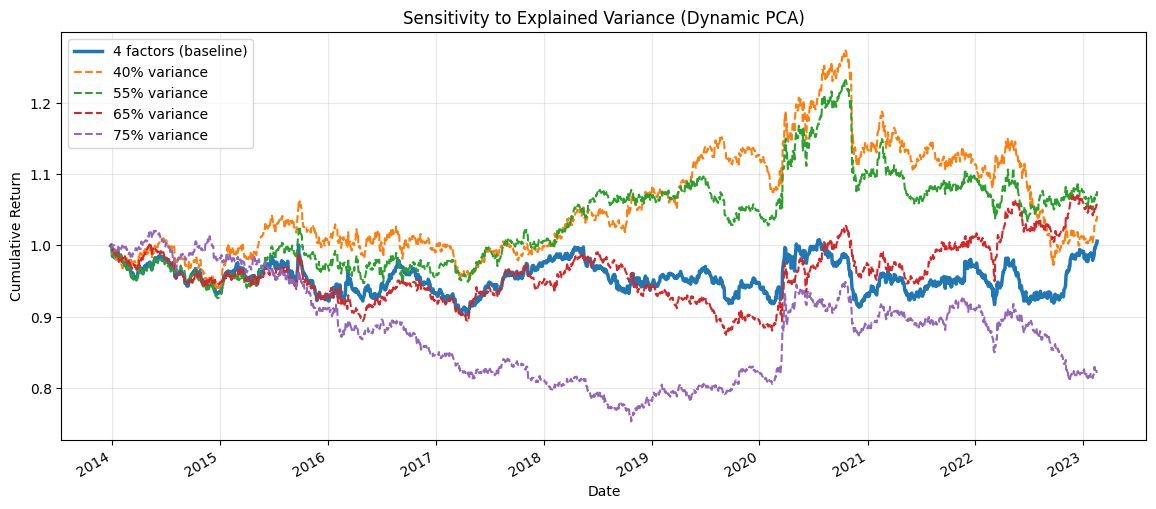

In [103]:
plt.figure(figsize=(14,6))

# Optional: order (baseline first)
ordered_keys = ["4_factors"] + [k for k in results_with_costs if k != "4_factors"]

for key in ordered_keys:
    perf = results_with_costs[key]

    # label propre
    if key == "4_factors":
        label = "4 factors (baseline)"
        linestyle = "-"
        linewidth = 2.5
    else:
        label = f"{int(key*100)}% variance"
        linestyle = "--"
        linewidth = 1.5

    perf.plot(
        label=label,
        linestyle=linestyle,
        linewidth=linewidth
    )

plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.title("Sensitivity to Explained Variance (Dynamic PCA)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

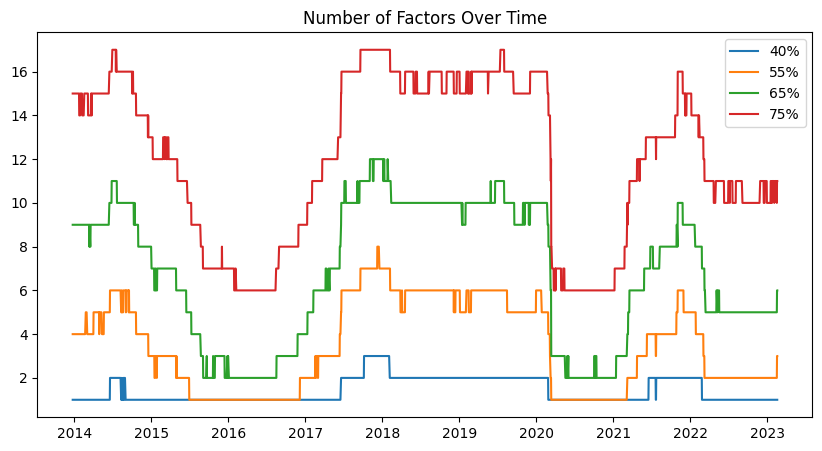

In [45]:
plt.figure(figsize=(10,5))

for var, series in n_factors_time_series.items():
    series.sort_index().plot(label=f"{int(var*100)}%")

plt.title("Number of Factors Over Time")
plt.legend()
plt.show()

# 7 Trading Time: Volume-Adjusted Returns

### Trading Time

The paper proposes measuring returns in **trading time** rather than calendar time.
The idea: price moves on low-volume days carry more information than moves on high-volume days.

The adjusted return:

$$\bar{R}_{i,t} = R_{i,t} \cdot \frac{\langle \delta V_i \rangle}{V_{i,t}}$$

where $\langle \delta V_i \rangle$ is the trailing average daily volume and $V_{i,t}$ is the actual volume on day $t$.

This amplifies price moves on quiet days and dampens moves on heavy-volume days.
We run the full backtest pipeline on these adjusted returns and compare to calendar time.


In [64]:
# ==========================================
# Data Preparation (Trading Time)
# ==========================================
returns_volume_adjusted = compute_volume_adjusted_returns(
    returns=performance, 
    volume=volume, 
    trailing_window=60
)

# ==========================================
# ROLLING BACKTEST (The Time Machine)
# ==========================================
estimation_window = 252
ou_estimation_window = 60
n_factors = 4
min_coverage = 0.95

all_positions_adj = {}
current_positions_adj = {}

print("Trading Time Backtest calculation in progress... (this may take a few minutes)")

for rebalance_date in returns_volume_adjusted.index:
    
    # 2a. Create the lookback window
    cur_performance_adj, cur_window_diagnostics_adj = prepare_rolling_estimation_window(
        returns=returns_volume_adjusted,
        rebalance_date=rebalance_date,
        lookback=estimation_window,
        min_coverage=min_coverage,
        return_diagnostics=True,
    )
    
    if cur_window_diagnostics_adj["row_count"] < estimation_window or cur_performance_adj.shape[1] == 0:
        continue

    reb_date = rebalance_date.to_pydatetime().date()

    # PCA
    factor_model_adj = estimate_factor_model(cur_performance_adj, n_factors=n_factors)
    
    # Residuals and Alphas Calculation (THE MISSING STEP)
    ou_residuals_output_adj = estimate_ou_window_residuals(
        cur_performance_adj, factor_model_adj["factors"], ou_estimation_window)
    
    alphas_adj = ou_residuals_output_adj["alphas"]
    cumulative_residuals_adj = ou_residuals_output_adj["residuals"]
    
    # O-U Parameters
    cum_residuals_ou_adj = cumulative_residuals_adj.iloc[-ou_estimation_window:]
    ou_params_adj = estimate_all_ou_parameters(cum_residuals_ou_adj, dt=1/252, center_ou_means=False)

    #  Filter
    valid_assets_adj = [a for a in ou_params_adj if ou_params_adj[a]["kappa"] > 252 / 30]

    # S-Score calculated based on TODAY'S model (NOW WITH ALPHAS)
    s_scores_adj_window = compute_s_score(cumulative_residuals_adj, ou_params_adj, alphas_adj, True)
    cur_s_scores_adj = s_scores_adj_window[valid_assets_adj].iloc[-1]

    #  Generate Signals
    current_positions_adj = update_positions(
        current_positions=current_positions_adj,
        cur_s_scores=cur_s_scores_adj,
        valid_assets=valid_assets_adj,
        s_bo=1.25, s_so=1.25, s_bc=0.50, s_sc=0.50,
    )
    all_positions_adj[reb_date] = current_positions_adj.copy()

print("Backtest completed!")

# ==========================================
# Weights, P&L, and Transaction Costs
# ==========================================
# Converts positions into a DataFrame and fixes dates
positions_adj_df = pd.DataFrame.from_dict(all_positions_adj, orient="index").fillna(0)
positions_adj_df.index = pd.to_datetime(positions_adj_df.index)

# Calculates percentage weights
weights_adj = compute_portfolio_weights(positions_adj_df)


Trading Time Backtest calculation in progress... (this may take a few minutes)
Backtest completed!


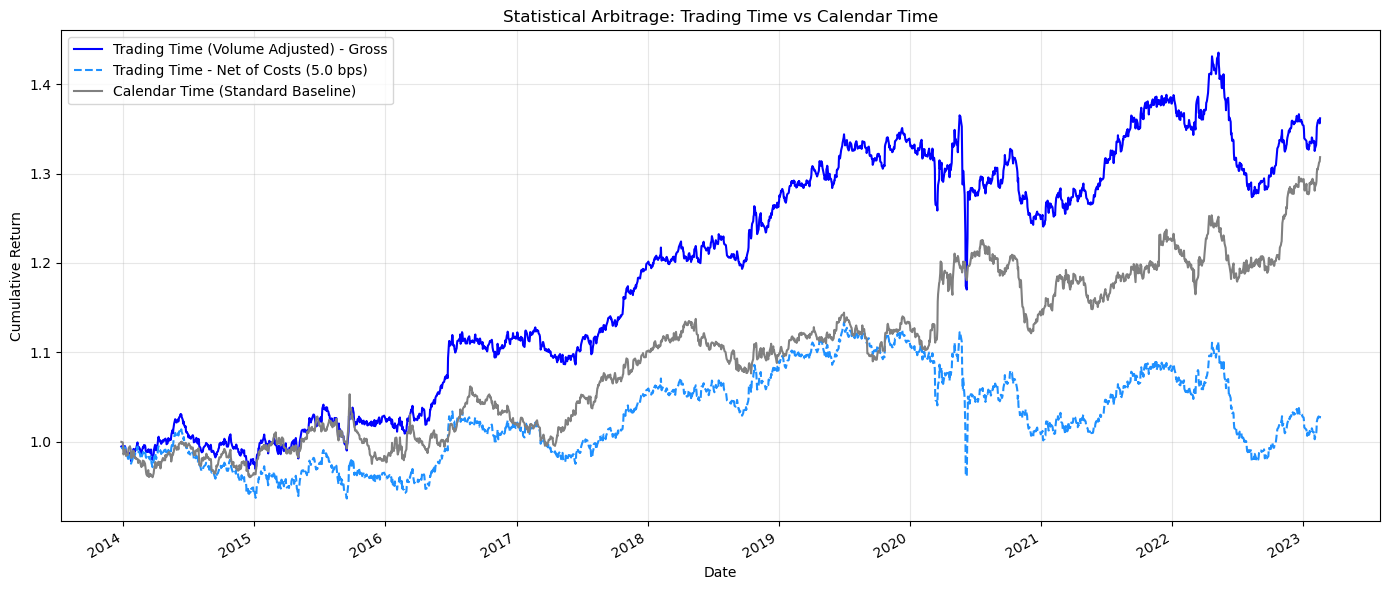

=== Trading Time Strategy Performance (Gross) ===
  Total Return:          36.90%
  Annualized Return:     3.43%
  Annualized Volatility: 6.08%
  Sharpe Ratio:          0.56
  Maximum Drawdown:      -14.27%

=== Trading Time Strategy Performance (Net of 5.0 bps) ===
  Total Return:          3.48%
  Annualized Return:     0.37%
  Annualized Volatility: 6.08%
  Sharpe Ratio:          0.06
  Maximum Drawdown:      -15.22%


In [65]:
# ==========================================
# Performance Analysis and Plot
# ==========================================

# Calculate cumulative returns for the Trading Time model
cumulative_returns_adj = backtest(weights_adj, performance)
cumulative_returns_adj_with_costs = backtest(
    weights_adj, performance, transaction_costs=transaction_costs
)

# Plotting
plt.figure(figsize=(14, 6))

# Curve 1 : Trading Time without costs (Gross)
cumulative_returns_adj.plot(
    label="Trading Time (Volume Adjusted) - Gross", 
    linewidth=1.5,
    color='blue'
)

# Curve 2: Trading Time with costs (Net)
cumulative_returns_adj_with_costs.plot(
    label=f"Trading Time - Net of Costs ({transaction_costs * 1e4:.1f} bps)", 
    linewidth=1.5,
    color='dodgerblue',
    linestyle='--'
)

# Curve 3: Base Model (Calendar Time)
cumulative_returns_base.plot(
    label="Calendar Time (Standard Baseline)", 
    linewidth=1.5,
    color='gray'
)

plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.title("Statistical Arbitrage: Trading Time vs Calendar Time")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ==========================================
# Print Metrics
# ==========================================

stats = compute_strategy_statistics(cumulative_returns_adj.dropna())
stats_with_costs = compute_strategy_statistics(cumulative_returns_adj_with_costs.dropna())

print("=== Trading Time Strategy Performance (Gross) ===")
print(f"  Total Return:          {stats['total_return']:.2%}")
print(f"  Annualized Return:     {stats['annualized_return']:.2%}")
print(f"  Annualized Volatility: {stats['annualized_volatility']:.2%}")
print(f"  Sharpe Ratio:          {stats['sharpe_ratio']:.2f}")
print(f"  Maximum Drawdown:      {stats['max_drawdown']:.2%}")

print(f"\n=== Trading Time Strategy Performance (Net of {transaction_costs * 1e4:.1f} bps) ===")
print(f"  Total Return:          {stats_with_costs['total_return']:.2%}")
print(f"  Annualized Return:     {stats_with_costs['annualized_return']:.2%}")
print(f"  Annualized Volatility: {stats_with_costs['annualized_volatility']:.2%}")
print(f"  Sharpe Ratio:          {stats_with_costs['sharpe_ratio']:.2f}")
print(f"  Maximum Drawdown:      {stats_with_costs['max_drawdown']:.2%}")